# InvoiceAI — Web demo (Gradio)

Starts the InvoiceAI web interface in Colab and gives you a **public link** you can open on any device or send to a client.

**Before you start:** `Runtime → Change runtime type → T4 GPU → Save`.

Do not run this notebook and `04_api.ipynb` at the same time: both load the model, and the T4 does not have memory for two copies.

## 1. Check the GPU

In [1]:
!nvidia-smi

Wed Sep 23 17:27:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   53C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Get the code

In [2]:
GITHUB_USER = "SamiHotak"
REPO_DIR = "/content/invoice-ai"

import os
if os.path.exists(REPO_DIR):
    !git -C {REPO_DIR} pull
else:
    !git clone https://github.com/{GITHUB_USER}/invoice-ai.git {REPO_DIR}
!ls {REPO_DIR}/ui {REPO_DIR}/samples

Cloning into '/content/invoice-ai'...
remote: Enumerating objects: 190, done.
remote: Counting objects: 100% (190/190), done.
remote: Compressing objects: 100% (177/177), done.
remote: Total 190 (delta 88), reused 13 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (190/190), 721.84 KiB | 15.69 MiB/s, done.
Resolving deltas: 100% (88/88), done.
/content/invoice-ai/samples:
sroie_1.jpg  sroie_2.jpg  sroie_3.jpg

/content/invoice-ai/ui:
gradio_app.py  __init__  __init__.py


## 3. Install requirements

This installs **gradio 5** next to **transformers 4** (Colab comes with gradio 6, which does not work with transformers 4).

A warning about `diffusers` and `huggingface-hub` may appear. It is harmless: we do not use diffusers.

**After this cell: `Runtime → Restart session`**, then continue with step 4 (do not run steps 2–3 again).

In [3]:
!pip install -q -r /content/invoice-ai/requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.7/87.7 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 83.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.3/27.3 MB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 103.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.5/63.5 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.6/325.6 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 462.4/462.4 kB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 83.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 972

## 4. Check the versions

This checks that gradio and the Qwen2.5-VL code of transformers work together. All lines should say OK.

In [4]:
import os, sys
os.chdir("/content/invoice-ai")
sys.path.insert(0, "/content/invoice-ai")

from importlib.metadata import version

versions = {name: version(name) for name in ["transformers", "huggingface-hub", "gradio", "torch"]}
for name, ver in versions.items():
    print(f"{name:16} {ver}")

major = lambda name: int(versions[name].split(".")[0])
assert major("transformers") == 4, "transformers must be 4.x. Run step 3 again and restart the session."
assert major("gradio") == 5, "gradio must be 5.x. Run step 3 again and restart the session."
assert major("huggingface-hub") == 0, "huggingface-hub must be 0.x. Run step 3 again and restart the session."
print("OK: versions")

import gradio as gr
from transformers import Qwen2_5_VLForConditionalGeneration  # noqa: F401
print("OK: gradio and Qwen2.5-VL can be imported together")

transformers     4.57.6
huggingface-hub  0.36.2
gradio           5.50.0
torch            2.11.0+cu130
OK: versions
OK: gradio and Qwen2.5-VL can be imported together


## 5. Load the model

Takes 1–3 minutes (the first time it downloads about 7 GB).

In [5]:
import logging, os, sys, torch
os.chdir("/content/invoice-ai")
sys.path.insert(0, "/content/invoice-ai")
logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s", force=True)

if not torch.cuda.is_available():
    raise RuntimeError(
        "No GPU found. Go to Runtime -> Change runtime type -> T4 GPU. "
        "If Colab gives you no GPU, wait a few hours or use Kaggle."
    )

from app.pipeline import get_pipeline

pipeline = get_pipeline()
pipeline.load()
print("Model loaded on", torch.cuda.get_device_name(0))

INFO app.ocr: Loading RapidOCR (PP-OCR models, ONNX Runtime, CPU).
[INFO] 2026-09-23 17:29:16,952 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-09-23 17:29:17,069 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.13/dist-packages/rapidocr/models/PP-OCRv6_det_small.onnx
[INFO] 2026-09-23 17:29:17,070 [RapidOCR] main.py:63: Using /usr/local/lib/python3.13/dist-packages/rapidocr/models/PP-OCRv6_det_small.onnx
[INFO] 2026-09-23 17:29:17,156 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-09-23 17:29:17,161 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/lib/python3.13/dist-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-09-23 17:29:17,162 [RapidOCR] main.py:63: Using /usr/local/lib/python3.13/dist-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-09-23 17:29:17,244 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-09-23 17:29:17,359 [Ra

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/3.98G [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

INFO app.extractor: Model loaded.


Model loaded on Tesla T4


## 6. Quick test (without the UI)

Runs one sample file through the pipeline. This proves the model still works after the new install.

In [8]:
   import ctypes, glob, sys

   # Colab fix: load the NVIDIA "nvrtc builtins" library by hand,
   # because Linux does not search the folder where pip put it.
   found = []
   for folder in sys.path:
       found += glob.glob(f"{folder}/nvidia/cu13/lib/libnvrtc-builtins.so.13*")
   for lib in found:
       ctypes.CDLL(lib, mode=ctypes.RTLD_GLOBAL)
   print("Loaded:", found or "nothing found")

   # Test the exact GPU operation that failed before
   import torch
   print(torch.tensor([[2, 3, 4]], device="cuda").prod(-1))

Loaded: ['/usr/local/lib/python3.13/dist-packages/nvidia/cu13/lib/libnvrtc-builtins.so.13.0']
tensor([24], device='cuda:0')


INFO app.ocr: OCR page 0: 45 lines (45 kept).
INFO app.pipeline: Processed sroie_1.jpg in 19.1 s.


File:  sroie_1.jpg
Total: 9.0  (confidence: high, source: model)
Time:  19.1 s


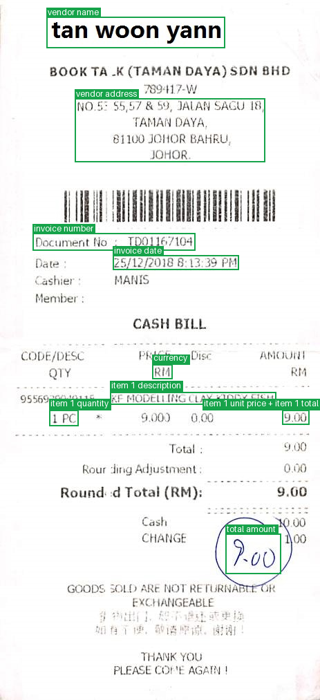

In [9]:
from pathlib import Path
from IPython.display import display

from app.pipeline import SUPPORTED_EXTENSIONS

sample = sorted(p for p in Path("samples").iterdir() if p.suffix.lower() in SUPPORTED_EXTENSIONS)[0]
doc = pipeline.process_file(sample)
total = doc.result.fields["total_amount"]
print(f"File:  {sample.name}")
print(f"Total: {total.value}  (confidence: {total.confidence}, source: {total.source})")
print(f"Time:  {doc.result.processing_seconds} s")

preview = doc.draw(0)
preview.thumbnail((500, 700))
display(preview)

## 7. Start the web app

Wait until you see a line like `Running on public URL: https://xxxx.gradio.live`. Open that link.

- The link works on any device (phone, laptop) while this Colab session is running.
- The first file takes a bit longer than the rest.
- Files are processed one at a time. If two people upload at once, the second waits in a queue.

In [10]:
from ui.gradio_app import launch_app

demo = launch_app(pipeline, share=True, prevent_thread_lock=True)

INFO httpx: HTTP Request: GET http://localhost:7860/gradio_api/startup-events "HTTP/1.1 200 OK"
INFO httpx: HTTP Request: HEAD http://localhost:7860/ "HTTP/1.1 200 OK"


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()


INFO httpx: HTTP Request: GET https://api.gradio.app/v3/tunnel-request "HTTP/1.1 200 OK"
INFO httpx: HTTP Request: GET https://cdn-media.huggingface.co/frpc-gradio-0.3/frpc_linux_amd64 "HTTP/1.1 200 OK"


* Running on public URL: https://8a06b3671866b3e697.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


INFO httpx: HTTP Request: HEAD https://8a06b3671866b3e697.gradio.live "HTTP/1.1 200 OK"


## 8. Stop the app

Run this when you are done (or after you change code and want to restart it).
After changing code on GitHub: `git pull` (step 2), **Runtime → Restart session**, then run steps 4, 5 and 7 again.

In [11]:
demo.close()
print("App stopped.")

Closing server running on port: 7860
App stopped.
